In [1]:
# %%
import scanpy as sc
from matplotlib import pyplot as plt
from pandas import get_dummies
from tensorflow_probability import math as tm
tfk = tm.psd_kernels

2026-04-01 12:15:11.466317: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [2]:
import tensorflow as tf
import tensorflow as tf
import tensorflow_probability as tfp
print(tf.__version__)        # нужно 2.5.0
print(tfp.__version__)       # нужно 0.13.0

2.5.0
0.13.0


In [3]:
import tensorflow as tf

print("TF version:", tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPUs visible to TF:", tf.config.list_physical_devices('GPU'))
print("Logical GPUs:", tf.config.list_logical_devices('GPU'))

TF version: 2.5.0
Built with CUDA: True
GPUs visible to TF: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]
Logical GPUs: [LogicalDevice(name='/device:GPU:0', device_type='GPU'), LogicalDevice(name='/device:GPU:1', device_type='GPU'), LogicalDevice(name='/device:GPU:2', device_type='GPU'), LogicalDevice(name='/device:GPU:3', device_type='GPU')]


2026-04-01 12:15:12.488110: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2026-04-01 12:15:12.576250: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:01:00.0 name: NVIDIA L40S computeCapability: 8.9
coreClock: 2.52GHz coreCount: 142 deviceMemorySize: 47.38GiB deviceMemoryBandwidth: 804.75GiB/s
2026-04-01 12:15:12.578094: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 1 with properties: 
pciBusID: 0000:61:00.0 name: NVIDIA L40S computeCapability: 8.9
coreClock: 2.52GHz coreCount: 142 deviceMemorySize: 44.40GiB deviceMemoryBandwidth: 804.75GiB/s
2026-04-01 12:15:12.580691: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 2 with properties: 
pciBusID: 0000:81:00.0 name: NVIDIA L40S computeCapability: 8.9
coreClock: 2.52GHz coreCount: 142 deviceMemorySize: 44.40GiB deviceMemoryBandwidth: 804.75GiB/s
2026-04-01 12:15:12.58432

In [4]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"   # например, хотим использовать только вторую GPU

import tensorflow as tf
tf.debugging.set_log_device_placement(True)

print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]


In [5]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import scanpy as sc

print("TF:", tf.__version__)
print("TFP:", tfp.__version__)
print("NumPy:", np.__version__)
print("Scanpy:", sc.__version__)

try:
    import gpflow
    print("GPflow:", gpflow.__version__)
except Exception as e:
    print("GPflow import failed:", repr(e))

TF: 2.5.0
TFP: 0.13.0
NumPy: 1.19.5
Scanpy: 1.8.0
GPflow import failed: ModuleNotFoundError("No module named 'gpflow'")


In [6]:
import inspect
from models import sf

print(sf.__file__)
print(inspect.getsource(sf.SpatialFactorization)[:4000])

/workspace/workspace/stereoseq_project/nsf-paper/models/sf.py
class SpatialFactorization(tf.Module):
  def __init__(self, J, L, Z, lik="poi", psd_kernel=tfk.MaternThreeHalves,
               nugget=1e-5, length_scale=0.1, disp="default",
               nonneg=False, isotropic=True, feature_means=None, **kwargs):
    """
    Non-negative process factorization

    Parameters
    ----------
    J : integer scalar
        Number of features in the multivariate outcome.
    L : integer scalar
        Number of desired latent Gaussian processes.
    T : integer scalar
        Number of desired non-spatial latent factors
    Z : 2D numpy array
        Coordinates of inducing point locations in input space.
        First dimension: 'M' is number of inducing points.
        Second dimension: 'D' is dimensionality of input to GP.
        More inducing points= slower but more accurate inference.
    lik: likelihood (Poisson or Gaussian)
    disp: overdispersion parameter initialization.
    --fo

In [7]:
#!pip install dill

In [8]:
from models import sf
from utils import misc,preprocess,training,postprocess,visualize

In [9]:
# slice_path = '../selected_slices/T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad'

In [10]:
slice_path = 'data/T1099_MT67_7M_Visual_Sub-CTX_V12_b100_filtered_J2000.h5ad'

In [11]:
#%% Data loading
ad = sc.read_h5ad(slice_path)
X = ad.obsm["spatial"]

In [12]:
ad

AnnData object with n_obs × n_vars = 15073 × 2000
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_counts', 'sizefactor'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'deviance_poisson'
    uns: 'bin_size', 'bin_type', 'key_record', 'log1p', 'merged', 'resolution', 'sn'
    obsm: 'spatial'
    layers: 'counts'

In [13]:
ad.layers['counts']

<15073x2000 sparse matrix of type '<class 'numpy.uint32'>'
	with 14330891 stored elements in Compressed Sparse Row format>

In [14]:
#raw count data for NSF
D,Dval = preprocess.anndata_to_train_val(ad, layer=None, train_frac=0.8,
                                         flip_yaxis=False)

In [15]:
D["Y"].shape

(12058, 2000)

In [16]:
D["X"].shape

(12058, 2)

In [17]:


Ntr,J = D["Y"].shape
Xtr = D["X"]
ad = ad[:Ntr,:]
#convert to tensorflow objects
Dtf = preprocess.prepare_datasets_tf(D,Dval=Dval)

In [18]:
# #%% Heatmap of true values
# hmkw1 = {"figsize":(8,1.9), "bgcol":"lightgray", "subplot_space":0.1, "marker":"s",
#         "s":2.9}
# Ftrue = ad.obsm["spfac"]
# fig,axes=visualize.multiheatmap(Xtr, Ftrue, (1,4), cmap="Blues", **hmkw1)

In [19]:
#%% Initialize inducing points
L = 10 #number of components
Z = misc.kmeans_inducing_pts(Xtr, 2000)
M = Z.shape[0] #number of inducing points
ker = tfk.MaternThreeHalves

In [20]:
print(type(ker))
print(ker)

<class 'abc.ABCMeta'>
<class 'tensorflow_probability.python.math.psd_kernels.matern.MaternThreeHalves'>


In [21]:
print("J =", J)
print("L =", L)
print("Z shape =", Z.shape)

J = 2000
L = 10
Z shape = (2000, 2)


In [22]:
D["Y"].shape

(12058, 2000)

In [23]:
Z.shape

(2000, 2)

In [24]:
from matplotlib import pyplot as plt

In [25]:
print(type(ker))
print(ker)

<class 'abc.ABCMeta'>
<class 'tensorflow_probability.python.math.psd_kernels.matern.MaternThreeHalves'>


In [26]:
Xtr.shape

(12058, 2)

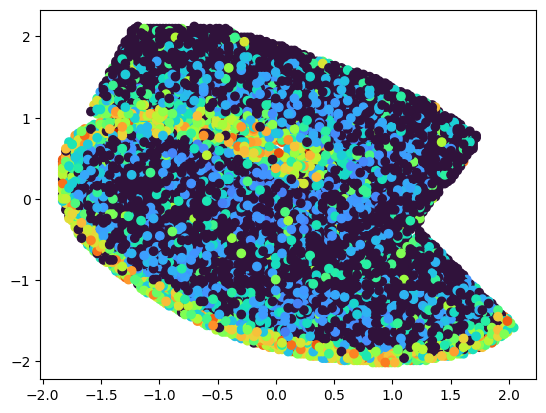

In [27]:
plt.scatter(Xtr[:,0],Xtr[:,1],c=D["Y"][:,2],cmap="turbo")

In [28]:
Xtr.shape

(12058, 2)

In [33]:
D["Y"]

array([[0.        , 0.        , 0.7922943 , ..., 1.2287382 , 0.        ,
        0.7922943 ],
       [0.        , 1.2918276 , 1.2918276 , ..., 0.84144473, 0.84144473,
        0.        ],
       [0.6884143 , 0.        , 0.        , ..., 1.0922968 , 0.        ,
        0.6884143 ],
       ...,
       [1.4958652 , 0.        , 0.        , ..., 1.8237095 , 0.        ,
        1.0048869 ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.5471476 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 1.1078185 , 0.7000598 ,
        0.        ]], dtype=float32)

In [35]:
pp = "res/T1099-7M/NSF_T1099_{}_M{}".format(L,ker.__name__, M)

In [36]:
pp

'res/T1099-7M/NSF_T1099_10_MMaternThreeHalves'

In [37]:
len(Dtf)

3

2026-04-01 12:16:22.187541: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


Temporary checkpoint directory: /tmp/tmpno5j5ygi
Instructions for updating:
The `interpolate_nondiscrete` flag is deprecated; instead use `force_probs_to_zero_outside_support` (with the opposite sense).


2026-04-01 12:16:49.995785: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2026-04-01 12:16:50.068808: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2445555000 Hz


0010 train: 1.559e+03, val: 1.566e+03
0020 train: 1.556e+03, val: 1.563e+03
0030 train: 1.554e+03, val: 1.562e+03
0040 train: 1.553e+03, val: 1.561e+03
0050 train: 1.552e+03, val: 1.560e+03
0060 train: 1.551e+03, val: 1.560e+03
0070 train: 1.551e+03, val: 1.559e+03
0080 train: 1.551e+03, val: 1.560e+03
0090 train: 1.550e+03, val: 1.559e+03
0100 train: 1.550e+03, val: 1.559e+03
0110 train: 1.550e+03, val: 1.559e+03, chg: 3.67e-05
0120 train: 1.550e+03, val: 1.559e+03, chg: 2.24e-05
0120 training complete, converged.
CPU times: user 11h 30min 30s, sys: 4h 42min 13s, total: 16h 12min 43s
Wall time: 13min 31s


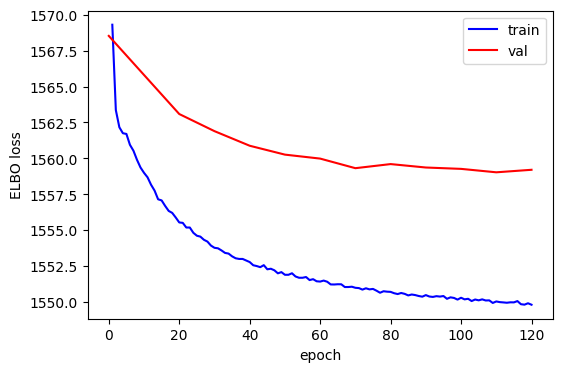

In [38]:
with tf.device("/CPU:0"):
    fit = sf.SpatialFactorization(J, L, Z, lik="poi", psd_kernel=ker,
                                      nugget=1e-5, length_scale=0.1, disp="default",
                                      nonneg=True, isotropic=True,
                                      feature_means=None)
    fit.init_loadings(D["Y"], X=Xtr, sz=D["sz"], shrinkage=0.3)
    tro = training.ModelTrainer(fit, lr=0.01, pickle_path=pp, max_to_keep=3)
    %time tro.train_model(*Dtf, S=3, verbose=True, num_epochs=10000, ckpt_freq=50, kernel_hp_update_freq=10,status_freq=10, span=100, tol=5e-5, pickle_freq=10, lr_reduce=0.5, maxtry=10)
    visualize.plot_loss(tro.loss)

In [39]:
from models import sf
from utils import misc,preprocess,training,postprocess,visualize

In [40]:
with tf.device("/CPU:0"):    
    insfh = postprocess.interpret_nsf(fit,Xtr,S=10,lda_mode=False)
    misc.pickle_to_file(insfh,"res/T1099-7M/insfh_T1099-7M_L10_M3000_spde.pickle")
    tgnames = [str(i) for i in range(1,L+1)]


In [41]:
hmkw = {"figsize":(15,6),"s":0.4,"marker":".","subplot_space":0,
        "spinecolor":"white"}

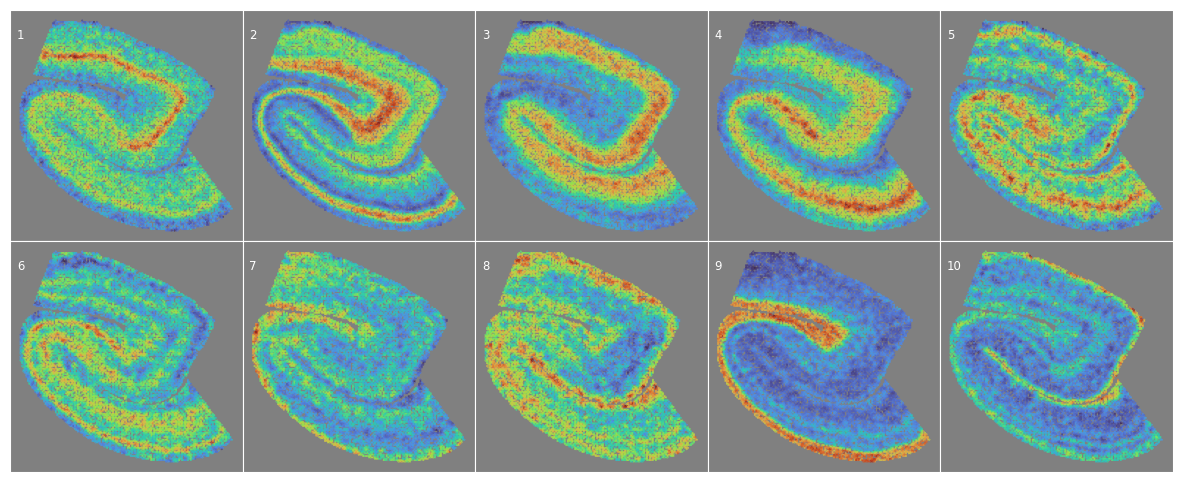

In [42]:
with tf.device("/CPU:0"): 
    fig,axes=visualize.multiheatmap(Xtr, np.sqrt(insfh["factors"]),
                                    (2,5), **hmkw)
    visualize.set_titles(fig, tgnames, x=0.03, y=.88, fontsize="small", c="white",
                         ha="left", va="top")
    fig.savefig("res/T1099-7M/T1099-7M_heatmap_nsf10_spde_spat.png",
                bbox_inches='tight', dpi=300)

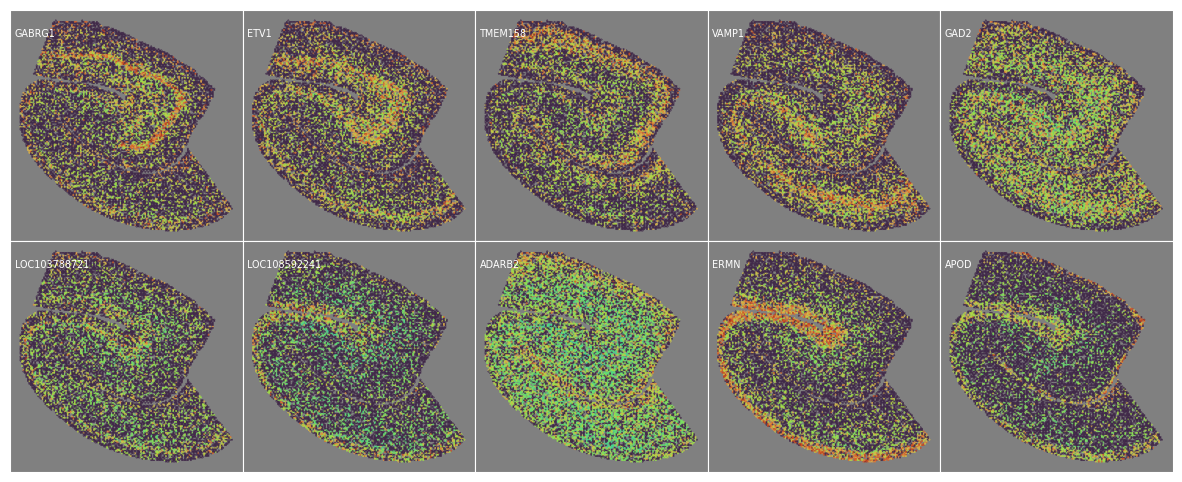

In [43]:
#%% Top genes for each latent dimension
with tf.device("/CPU:0"): 
    W = insfh["loadings"]#*insf["totals"][:,None]
    W[np.isnan(W)] = 0.0
    topgenes = W.argmax(axis=0).tolist()
    tgnames = ad.var.index[topgenes]
    Ytg = D["Y"][:,topgenes]/D["sz"]
    fig,axes=visualize.multiheatmap(Xtr, np.sqrt(Ytg), (2,5), **hmkw)
    visualize.set_titles(fig, tgnames, x=0.02, y=.88, fontsize="x-small", c="white",
                         ha="left", va="top")
    fig.savefig("res/T1099-7M/T1099-7M_heatmap_nsfh20_spde_spat_genes.png",
                bbox_inches='tight', dpi=300)

In [44]:
import pandas as pd

In [45]:
#save loadings to disk for further interpretation
with tf.device("/CPU:0"): 
    # W = W*insfh["totals"][:,None]
    Wdf=pd.DataFrame(W, index=ad.var.index, columns=range(1,L+1))
    Wdf.to_csv("res/T1099-7M/T1099-7M_nsfh20_spde_loadings.csv")

In [46]:
Wdf[1].sort_values()

GFAP      0.000000
APOD      0.000000
IGFBP5    0.000000
GSN       0.000000
TLE4      0.000000
            ...   
IGFBP4    0.359218
RARB      0.364145
FOXP2     0.407541
TRHDE     0.413913
GABRG1    0.439844
Name: 1, Length: 2000, dtype: float32